(gene_set_scoring)=

# Gene-set activity scoring primer

Single cell readouts on single genes can be sparse and heavily noisy. This is often driven by dropout, which can zero out a marker in cells that express it, and then one highly expressed gene can dominate expression. Gene-set scoring fixes this by collapsing a whole program; a pathway, a cell state, a lineage signature; into one number per cell that is more robust than any member gene alone.

CyteArc offers two ways to compute that number. WAGGR (Weighted Aggregate) takes a weighted mean of normalized gene expression, so strongly expressed genes can pull harder and can push in opposite directions. AUCell ignores expression values entirely after ranking each cell's genes, then measures how early the signature's targets appear among the top ranks, with its scores falling between 0-1. WAGGR can be used to gain an idea of the magnitude of a program, whereas AUCell can tell you about rank recovery. Rank recovery can be conceptualized as how early the signature of interest appears among that cell's top-ranked genes.

## Load the prepared dataset

We first begin by loading in the prepared dataset. For context, when we do our activity scoring, the data is streamed directly from the raw counts: AUCell ranks those raw counts, while WAGGR applies library-size normalization for its own scoring function.

In [1]:
# Import tools for writing a temporary GMT file.
from pathlib import Path
from tempfile import TemporaryDirectory

# Import plotting and table tools for inspecting the scores.
import matplotlib.pyplot as plt
import pandas as pd

# Import CyteArc's datastore and gene-set scoring methods.
import cytearc

# Keep warnings visible while hiding routine progress messages.
cytearc.configure_output(level='WARNING', progress=False)

# Download the prepared PBMC store and its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='cytearc_datasets',
    zarr=True,
)

# Open the store so scoring can save its results.
ds = cytearc.DataStore(f'{dataset}/data.zarr', nthreads=4)

# Reuse the saved analysis and its selected cells.
run = ds.pipeline.open(label='docs_default')

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:22.435356Z | Wall time: 13.335 s

## Read and inspect gene-sets

For your own analysis, replace these demonstration signatures with **your own Gene Matrix Transposed (GMT) file.** The file stores one gene program per line.

In [2]:
# Keep the demonstration GMT file in a temporary folder.
input_directory = TemporaryDirectory()

# Choose the filename for the three PBMC signatures.
gmt_path = Path(input_directory.name) / 'pbmc_signatures.gmt'

# Write five target genes for each demonstration signature.
gmt_path.write_text(
    'T_cell\tna\tCD3D\tCD3E\tTRAC\tLTB\tIL7R\n'
    'B_cell\tna\tMS4A1\tCD79A\tCD37\tCD74\tHLA-DRA\n'
    'Myeloid\tna\tLST1\tS100A8\tS100A9\tCTSS\tFCER1G\n',
    encoding='utf-8',
)

# Read the GMT as a table of signature names and target genes.
gene_sets = cytearc.read_gmt(gmt_path)

# Inspect the genes assigned to each signature.
gene_sets

,source,target
0,T_cell,CD3D
1,T_cell,CD3E
2,T_cell,TRAC
3,T_cell,LTB
4,T_cell,IL7R
5,B_cell,MS4A1
6,B_cell,CD79A
7,B_cell,CD37
8,B_cell,CD74
9,B_cell,HLA-DRA


Started: 2026-10-08T11:03:35.773026Z | Wall time: 0.020 s

Targets are matched to active RNA feature names without case sensitivity, meaning that any match regardless of capitalization will be selected. Missing targets do not need to be removed from the input table, as CYTEARC automatically handles this. A target that matches several active features, such as a gene symbol shared by two feature ids, is ambiguous and is ignored with a warning by default.

In [3]:
# Normalize gene-name case before checking signature overlap.
available = {str(name).upper() for name in ds.RNA.feats.fetch_all('names')}

# Mark each target whose name occurs in this assay.
matched_targets = gene_sets.assign(matched=gene_sets['target'].str.upper().isin(available))

# Compare matched and total target counts for each signature.
matched_targets.groupby('source')['matched'].agg(['sum', 'count'])

,sum,count
source,,
B_cell,5,5
Myeloid,5,5
T_cell,5,5


Started: 2026-10-08T11:03:35.796173Z | Wall time: 0.063 s

In our case, all five genes in each of the three signatures are present in the dataset.

## Start with WAGGR

WAGGR calculates a weighted mean of library-size-normalized expression by default.
When the input has no weight column, every target gene has weight one.
`tmin` is the minimum number of matched genes a signature needs to be scored; anything below it is skipped. Our sample gene-sets have only five genes each, so `tmin=3` lets a signature survive one or two missing genes, where the default of five would drop it outright.

This comparison uses the complete assay feature universe for both methods:

In [4]:
# Reuse the cells selected by the saved analysis.
cell_selection = run['analysis_cell_selection']

# Include every RNA feature in the scoring universe.
all_features = ds.features.universe(from_assay='RNA')

# Show the number of cells and genes used by both methods.
{'cells': int(run.cells.fetch_all('I').sum()), 'genes': ds.RNA.feats.N}

{'cells': 3948, 'genes': 33538}

Started: 2026-10-08T11:03:35.861523Z | Wall time: 0.221 s

In [5]:
# Aggregate normalized expression for each demonstration signature.
waggr = ds.scores.waggr(
    gene_sets,
    cell_selection,
    features=all_features,
    tmin=3,
)

# Keep the same signature order throughout the comparison.
score_sources = ['T_cell', 'B_cell', 'Myeloid']

# Load only the three signatures compared in this tutorial.
waggr_result = ds.scores.load(waggr, sources=score_sources)

# Materialize the three score columns as a table.
waggr_scores = pd.DataFrame(
    waggr_result.data.compute(),
    columns=list(waggr_result.source_names),
)

# Inspect the range and median of each signature's WAGGR scores.
waggr_scores.describe().loc[['min', '50%', 'max']]

,T_cell,B_cell,Myeloid
min,0.000000,0.000000,0.000000
50%,0.562968,0.172488,0.047424
max,2.551281,7.278358,25.161978


Started: 2026-10-08T11:03:36.085497Z | Wall time: 0.847 s

The results from WAGGR are not confined from 0-1 like AUCell.

## Score rank recovery with AUCell

Since AUCell scores each cell by recovery among its top-ranked genes, it first needs to know what universe to rank. The required features argument sets that universe: here all_features ranks the complete gene list, but AUCell only uses the top 5% of genes to calculate its recovery.

In [6]:
# Score recovery of each signature among the top-ranked genes.
aucell = ds.scores.aucell(
    gene_sets,
    cell_selection,
    features=all_features,
    tmin=3,
)

# Load AUCell scores in the same signature order as WAGGR.
aucell_result = ds.scores.load(aucell, sources=score_sources)

# Materialize the three AUCell score columns as a table.
aucell_scores = pd.DataFrame(
    aucell_result.data.compute(),
    columns=list(aucell_result.source_names),
)

# Inspect the range and median of each signature's AUCell scores.
aucell_scores.describe().loc[['min', '50%', 'max']]

,T_cell,B_cell,Myeloid
min,0.000000,0.000000,0.000000
50%,0.678495,0.308961,0.075030
max,0.933692,0.975508,0.985544


Started: 2026-10-08T11:03:36.937166Z | Wall time: 34.298 s

An AUCell score of 0 means no signature genes are recovered before the top-rank cutoff; a gene exactly at the cutoff contributes no area. A score of 1 means the signature achieves the maximum possible recovery at the top of that cell's ranking.

## Visualize the AUCell and WAGGR

To visualize the results from AUCell, we can simply plot the recovery score on a UMAP of the cells.

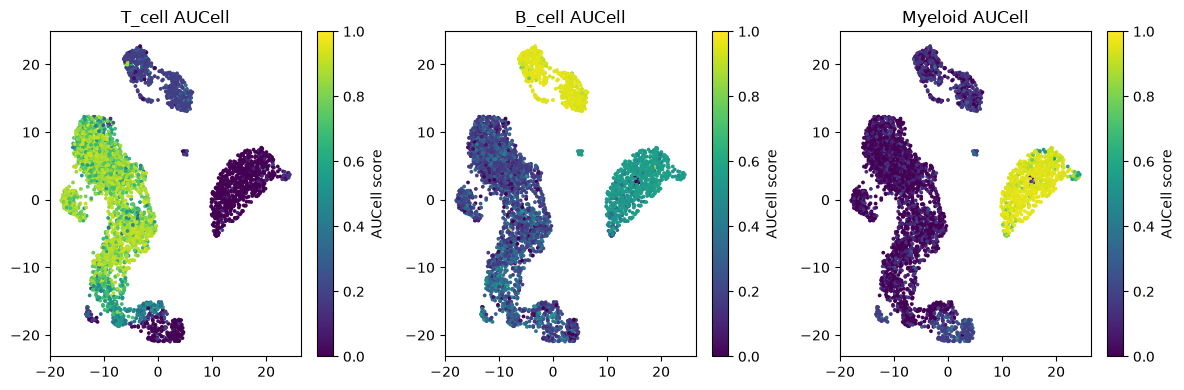

Started: 2026-10-08T11:04:11.243804Z | Wall time: 1.204 s

In [7]:
# Read the saved UMAP coordinates in the score table's cell order.
umap = run.cells.to_pandas_dataframe(['umap_1', 'umap_2'])

# Create one panel per signature.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))

# Map each signature's AUCell score onto the same UMAP.
for axis, source in zip(axes, score_sources, strict=True):

    # Use the common zero-to-one scale for every signature.
    points = axis.scatter(
        umap['umap_1'],
        umap['umap_2'],
        c=aucell_scores[source],
        s=3,
        vmin=0,
        vmax=1,
    )

    # Identify the signature shown in the panel.
    axis.set_title(f'{source} AUCell')

    # Label the score scale used to color the cells.
    figure.colorbar(points, ax=axis, label='AUCell score')

# Make room for panel titles and color scales.
figure.tight_layout()

# Display the three signature maps.
plt.show()

AUCell scores highlight lineage-consistent regions: T-cell, B-cell, and Myeloid scores peak in separate parts of the UMAP when those populations are present.


To compare both methods, take the Myeloid signature for example: we can create a table comparing the results; remember, their numerical scales differ.

In [8]:
# Align the Myeloid signature's scores from both methods by cell.
myeloid_compare = pd.DataFrame(
    {
        'Myeloid_WAGGR': waggr_scores['Myeloid'],
        'Myeloid_AUCell': aucell_scores['Myeloid'],
    }
)

# Compare the distributions without assuming a shared numerical scale.
myeloid_compare.describe()

,Myeloid_WAGGR,Myeloid_AUCell
count,3948.000000,3948.000000
mean,1.246021,0.229799
std,3.026997,0.343544
min,0.000000,0.000000
25%,0.022398,0.000000
50%,0.047424,0.075030
75%,0.137805,0.187366
max,25.161978,0.985544


Started: 2026-10-08T11:04:12.457807Z | Wall time: 0.027 s

We can also compare WAGGR and AUCell scores for the Myeloid signature across all selected cells in a scatter plot.

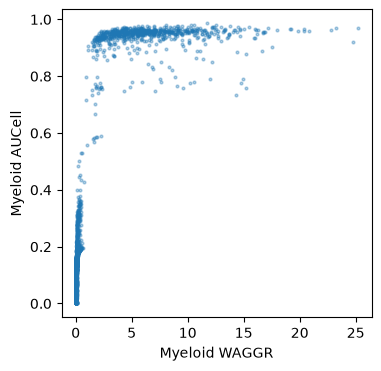

Started: 2026-10-08T11:04:12.491835Z | Wall time: 0.242 s

In [9]:
# Create an axis for the comparison between scoring methods.
figure, axis = plt.subplots(figsize=(4, 4))

# Plot one point per cell using its two Myeloid signature scores.
axis.scatter(
    myeloid_compare['Myeloid_WAGGR'],
    myeloid_compare['Myeloid_AUCell'],
    s=4,
    alpha=0.35,
)

# Label the expression-based score on the horizontal axis.
axis.set_xlabel('Myeloid WAGGR')

# Label the rank-recovery score on the vertical axis.
axis.set_ylabel('Myeloid AUCell')

# Display the comparison between the two scoring methods.
plt.show()

Look for cells with high scores under both methods and cells where the methods disagree.

## Optional: use a signature with weights

Add weights when the WAGGR source gives some genes more say than others: amplifying strong genes, silencing weak ones, or setting genes against each other in opposite directions. To adjust for this, add a `weight` column to the input table, as without one, every gene counts equally at weight one. WAGGR's default `mode="wmean"` divides the weighted sum by the sum of absolute weights, keeping scores comparable across signatures of different sizes, while `mode="wsum"` leaves the total unscaled, so comparability falls.

## Important caveats to consider regarding gene-set activity scoring

- **Restricting AUCell's ranking universe (e.g., passing HVGs):** AUCell evaluates target recovery within the top 5% of whatever gene list is provided in features. Supplying a reduced subset like highly variable genes instead of the full feature universe distorts background gene ranks and artificially inflates or skews recovery scores, thus ensure you provide the universe of all genes.
- **Unmatched gene identifiers and rigid tmin thresholds:** If gene symbols in the GMT file fail to match assay feature names or map ambiguously, target genes are dropped. When remaining valid targets fall below tmin, CyteArc silently skips the entire signature rather than scoring the surviving subset. If no signatures remain, scoring raises an error.
- **Comparing WAGGR scores across inconsistent transformations:** Unlike AUCell's bounded rank scores (0 to 1), WAGGR values are unbounded magnitude metrics sensitive to log_transform, weighting mode (wmean vs. wsum), and library normalization. Comparing WAGGR runs with different parameter settings or directly comparing WAGGR to AUCell confounds mathematical scaling with true biological differences.